<a href="https://colab.research.google.com/github/chiranjeevi-manike/Deep-Learning/blob/main/Gradient_Optimization_Algorithms.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Training with SGD...


/usr/local/lib/python3.11/dist-packages/keras/src/layers/core/dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Training with Adam...
Training with RMSprop...
Training with Adagrad...
Training with Adadelta...
Training with Nadam...


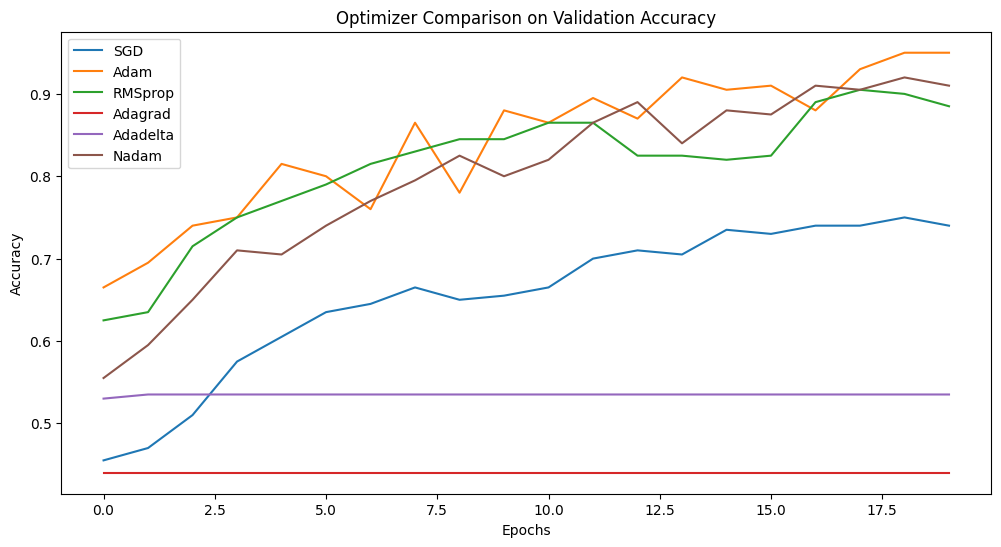

In [1]:
import numpy as np
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
from tensorflow.keras.optimizers import SGD, Adam, RMSprop, Adagrad, Adadelta, Nadam
import matplotlib.pyplot as plt

# Generate synthetic dataset
np.random.seed(42)
x_train = np.random.rand(1000, 10)
y_train = (np.sum(x_train, axis=1) > 5).astype(int)  # Binary classification
x_test = np.random.rand(200, 10)
y_test = (np.sum(x_test, axis=1) > 5).astype(int)

# Define function to create model
def create_model():
    model = Sequential([
        Dense(32, activation='relu', input_shape=(10,)),
        Dense(16, activation='relu'),
        Dense(1, activation='sigmoid')
    ])
    return model

# List of optimizers to compare
optimizers = {
    'SGD': SGD(),
    'Adam': Adam(),
    'RMSprop': RMSprop(),
    'Adagrad': Adagrad(),
    'Adadelta': Adadelta(),
    'Nadam': Nadam()
}

# Dictionary to store results
history_results = {}

# Train and evaluate each optimizer
for opt_name, optimizer in optimizers.items():
    print(f'Training with {opt_name}...')
    model = create_model()
    model.compile(optimizer=optimizer, loss='binary_crossentropy', metrics=['accuracy'])
    history = model.fit(x_train, y_train, validation_data=(x_test, y_test), epochs=20, batch_size=32, verbose=0)
    history_results[opt_name] = history

# Plot results
plt.figure(figsize=(12, 6))
for opt_name, history in history_results.items():
    plt.plot(history.history['val_accuracy'], label=opt_name)

plt.title('Optimizer Comparison on Validation Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()
plt.show()
